# 06 — The Best Model We Can Build

**Hack4Dev Iraq 2026 · Exoplanet Data Challenge · Track F**
Team: Mostafa & Sara

This notebook is the final version of the AI part. Compared with notebook 03 it changes four things,
each one for a measured reason:

| Change | Why |
|---|---|
| Built on the **de-trended** light curves (notebook 05) | the systematic error was ~5x the random error; cleaning the data helps more than any model |
| **Injection happens before de-trending** | otherwise we would measure a sensitivity we do not actually have |
| Candidate times restricted to the **middle 60%** of each night | in notebook 03 the model could partly guess from *when* a dip happened; now both classes live in the same time range |
| **Leave-one-night-out** validation | 16 nights = 16 independent tests, and we report the spread, not one number |

Three models are compared on identical data and identical splits:

1. **Random Forest** — the baseline from notebook 03
2. **Histogram Gradient Boosting** — the strongest classical model for tables of this size
3. **Two-branch neural network** — a 1D-CNN reading the raw light-curve window, plus a dense branch reading the observing conditions

> **Note on LightGBM/XGBoost:** both fail to load on this machine because macOS lacks the OpenMP runtime
> they depend on. `HistGradientBoostingClassifier` is the same histogram-gradient-boosting algorithm,
> ships inside scikit-learn, and keeps this project runnable anywhere — so we use it.

In [1]:
# Step 1: setup
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (average_precision_score, precision_recall_curve, precision_score,
                             recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay)
import torch
import torch.nn as nn

warnings.filterwarnings("ignore")
rng = np.random.default_rng(42)
torch.manual_seed(42)

OUTPUT_DIR = Path("..") / "outputs"
lc = pd.read_csv(OUTPUT_DIR / "light_curves.csv")
quality = pd.read_csv(OUTPUT_DIR / "photometry_quality.csv")
nights = [(t, n) for t, n in zip(quality[quality.stars > 0].target, quality[quality.stars > 0].night)]
print("usable nights:", len(nights), "| torch", torch.__version__)

usable nights: 19 | torch 2.14.0


## Step 2 — The pipeline, in the right order

The order matters. We inject the artificial transit into the **raw** curve, and only then clean and search.
If we injected after cleaning, the transit would never face the de-trending step, and we would report a
sensitivity better than the real one.

```
raw night matrix -> (optionally inject a transit) -> de-trend (k=3) -> search for dips -> features
```

In [2]:
# Step 2: the building blocks (de-trending is the same function as notebook 05)
K = 3
WINDOW = 64          # points kept around each candidate for the neural network

def matrix_for(target, night):
    g = lc[(lc.target == target) & (lc.night == night)]
    M = g.pivot_table(index="star_id", columns="mjd", values="rel_flux")
    return M.dropna(axis=1, how="any")

def detrend(A, k=K):
    """Leave-one-out removal of the k strongest patterns shared by the other stars."""
    cleaned = np.empty_like(A)
    for j in range(A.shape[0]):
        others = np.delete(A, j, axis=0)
        others = others - others.mean(axis=1, keepdims=True)
        _, _, patterns = np.linalg.svd(others, full_matrices=False)
        basis = patterns[:k]
        y = A[j] - A[j].mean()
        weights, *_ = np.linalg.lstsq(basis.T, y, rcond=None)
        cleaned[j] = A[j] - basis.T @ weights
    return cleaned

def conditions_for(target, night, mjds):
    """Observing conditions lined up with the matrix columns."""
    g = lc[(lc.target == target) & (lc.night == night)].drop_duplicates("mjd").set_index("mjd")
    return g.reindex(mjds)[["altitude_deg", "weather", "sky_median", "dx", "dy"]]

## Step 3 — Build the dataset

For every star on every night we produce two versions: one untouched (its dips are false positives) and one
with an injected transit (that window is a true positive). Candidate centres are restricted to the middle 60%
of the night for **both** classes, so the model cannot separate them by time of night.

For each candidate we store both kinds of input:

- **11 numbers** (depth, signal-to-noise, shape, conditions) for the tree models
- **a 2 x 64 window** (the star's own cleaned curve, and the average of the other stars) for the neural network

In [3]:
# Step 3: build candidates, features and windows
def describe(curve, others_curve, cond, centre, width_pts, night_scatter):
    n = len(curve)
    lo, hi = max(0, centre - width_pts // 2), min(n, centre + width_pts // 2)
    inside = np.zeros(n, bool); inside[lo:hi] = True
    outside = ~inside
    if inside.sum() < 3 or outside.sum() < 10:
        return None
    level_out = np.median(curve[outside]); level_in = np.mean(curve[inside])
    noise = np.std(curve[outside]) / np.sqrt(inside.sum())
    depth = (level_out - level_in) / level_out * 100
    others_in = np.mean(others_curve[inside]); others_out = np.median(others_curve[outside])
    return {
        "depth_%": depth,
        "snr": depth / 100 * level_out / noise if noise > 0 else 0.0,
        "width_pts": width_pts,
        "n_in": int(inside.sum()),
        "others_dip_%": (others_out - others_in) / others_out * 100,
        "night_scatter_%": night_scatter,
        "altitude_mean": float(cond.altitude_deg.values[inside].mean()),
        "altitude_change": float(cond.altitude_deg.values[inside].mean() - cond.altitude_deg.values[outside].mean()),
        "weather_mean": float(cond.weather.values[inside].mean()),
        "sky_change_%": float(cond.sky_median.values[inside].mean() / np.median(cond.sky_median.values[outside]) - 1) * 100,
        "drift_in_window": float(np.hypot(np.ptp(cond.dx.values[inside]), np.ptp(cond.dy.values[inside]))),
    }

def window_of(curve, others_curve, centre):
    """A fixed-length 2-channel window centred on the candidate, padded at the edges."""
    half = WINDOW // 2
    idx = np.clip(np.arange(centre - half, centre + half), 0, len(curve) - 1)
    a = curve[idx]; b = others_curve[idx]
    a = a / np.median(a) - 1
    b = b / np.median(b) - 1
    return np.stack([a, b])

rows, windows = [], []
for target, night in nights:
    M = matrix_for(target, night)
    if M.shape[0] < 10 or M.shape[1] < 40:
        continue
    cond = conditions_for(target, night, M.columns.values)
    n_times = M.shape[1]
    centre_lo, centre_hi = int(0.2 * n_times), int(0.8 * n_times)     # middle 60% only
    widths = [w for w in (7, 13, 20) if w < n_times // 3]

    for star_pos in range(M.shape[0]):
        for injected in (False, True):
            A = M.values.copy()
            true_centre = None
            if injected:
                depth = rng.uniform(1.0, 5.0)
                width = int(rng.choice(widths))
                true_centre = int(rng.integers(centre_lo, centre_hi))
                lo, hi = max(0, true_centre - width // 2), min(n_times, true_centre + width // 2)
                A[star_pos, lo:hi] *= (1 - depth / 100)

            cleaned = detrend(A, K)                      # de-trend AFTER injection
            curve = cleaned[star_pos]
            others = np.delete(cleaned, star_pos, axis=0).mean(axis=0)
            night_scatter = float(np.std(curve)) * 100

            if injected:
                candidates = [(true_centre, int(rng.choice(widths)))]
            else:
                candidates = [(int(c), int(w)) for c in rng.integers(centre_lo, centre_hi, 3) for w in widths]

            for centre, width in candidates:
                f = describe(curve, others, cond, centre, width, night_scatter)
                if f is None:
                    continue
                f.update(target=target, night=night, star=star_pos, label=int(injected))
                if injected:
                    f["injected_depth_%"] = depth
                rows.append(f)
                windows.append(window_of(curve, others, centre))

data = pd.DataFrame(rows)
X_window = np.array(windows, dtype=np.float32)
print("candidates:", len(data), "| windows:", X_window.shape)
print(data.label.value_counts().rename({0: "false positives", 1: "injected transits"}))

candidates: 5800 | windows: (5800, 2, 64)
label
false positives      5160
injected transits     640
Name: count, dtype: int64


In [4]:
# Step 3b: prepare the inputs
FEATURES = ["depth_%", "snr", "width_pts", "n_in", "others_dip_%", "night_scatter_%",
            "altitude_mean", "altitude_change", "weather_mean", "sky_change_%", "drift_in_window"]

keep = data[FEATURES].notna().all(axis=1).values
data = data[keep].reset_index(drop=True)
X_window = X_window[keep]
X = data[FEATURES].values.astype(np.float32)
y = data.label.values
groups = (data.target + " " + data.night).values
print("final dataset:", X.shape, "| windows:", X_window.shape, "| nights:", len(np.unique(groups)))

final dataset: (5800, 11) | windows: (5800, 2, 64) | nights: 16


## Step 4 — The two-branch neural network

The network reads the candidate in two ways at once and joins them:

- a **1D-CNN** over the 2 x 64 window — it learns the *shape* of the dip, and can compare the star with the others
- a small **dense branch** over the 11 numbers — the conditions and summary statistics

A single-channel CNN would be blind to the most useful fact we have: whether the other stars dipped at the
same moment. That is why channel 2 exists.

In [5]:
# Step 4: the model definition
class TwoBranchNet(nn.Module):
    def __init__(self, n_features, window=WINDOW):
        super().__init__()
        self.cnn = nn.Sequential(                       # reads the 2 x 64 light-curve window
            nn.Conv1d(2, 16, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
        )
        self.dense = nn.Sequential(                     # reads the 11 numbers
            nn.Linear(n_features, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 16), nn.ReLU(),
        )
        self.head = nn.Sequential(                      # decides using both
            nn.Linear(32 + 16, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, window, features):
        return self.head(torch.cat([self.cnn(window), self.dense(features)], dim=1)).squeeze(1)


def train_network(Xw_tr, Xf_tr, y_tr, Xw_te, Xf_te, epochs=25):
    """Train on one split and return probabilities for the held-out night."""
    mean, std = Xf_tr.mean(0), Xf_tr.std(0) + 1e-8               # scale features using TRAIN data only
    Xf_tr, Xf_te = (Xf_tr - mean) / std, (Xf_te - mean) / std
    net = TwoBranchNet(Xf_tr.shape[1])
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    lossf = nn.BCEWithLogitsLoss()
    tw, tf, ty = map(torch.tensor, (Xw_tr, Xf_tr, y_tr.astype(np.float32)))
    ds = torch.utils.data.TensorDataset(tw, tf, ty)
    dl = torch.utils.data.DataLoader(ds, batch_size=256, shuffle=True)
    net.train()
    for _ in range(epochs):
        for bw, bf, by in dl:
            opt.zero_grad()
            loss = lossf(net(bw, bf), by)
            loss.backward()
            opt.step()
    net.eval()
    with torch.no_grad():
        return torch.sigmoid(net(torch.tensor(Xw_te), torch.tensor(Xf_te))).numpy()

## Step 5 — Leave-one-night-out

Every night takes a turn as the test set while the models train on all the other nights.
Nothing from the tested night is ever seen during training — not even to scale the features.

In [6]:
# Step 5: train and test all three models, one night at a time
unique_nights = np.unique(groups)
scores = {name: np.zeros(len(y)) for name in ["Random Forest", "HistGradientBoosting", "Two-branch NN"]}

for i, night in enumerate(unique_nights, 1):
    test = groups == night
    train = ~test
    if y[train].sum() < 20 or y[test].sum() < 3:
        continue

    rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=-1)
    rf.fit(X[train], y[train])
    scores["Random Forest"][test] = rf.predict_proba(X[test])[:, 1]

    hgb = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.06, max_leaf_nodes=31, random_state=0)
    hgb.fit(X[train], y[train])
    scores["HistGradientBoosting"][test] = hgb.predict_proba(X[test])[:, 1]

    scores["Two-branch NN"][test] = train_network(X_window[train], X[train], y[train], X_window[test], X[test])
    print(f"  [{i}/{len(unique_nights)}] {night} done")

print("\nall nights tested")

  [1/16] CoRoT-2 2026-08-09 done
  [2/16] CoRoT-2 2026-08-16 done
  [3/16] HATP-10 2026-09-05 done
  [4/16] Qatar-1 2026-08-18 done
  [5/16] Qatar-1 2026-08-21 done
  [6/16] TRES-3 2026-08-10 done
  [7/16] TRES-3 2026-08-14 done
  [8/16] TRES-3 2026-08-27 done
  [9/16] TRES-3 2026-08-31 done
  [10/16] TRES-5 2026-08-17 done
  [11/16] TRES-5 2026-08-20 done
  [12/16] TRES-5 2026-08-26 done
  [13/16] TRES-5 2026-08-29 done
  [14/16] TRES-5 2026-09-01 done
  [15/16] TRES-5 2026-09-04 done
  [16/16] WASP-2 2026-08-24 done

all nights tested


## Step 6 — Results

`average precision` is the headline number (the area under the precision-recall curve — it does not depend on
where we set the threshold). We also report the false positives at the recall the simple baseline achieves,
which is the number the challenge actually cares about.

In [7]:
# Step 6: compare everything against the simple rule
baseline_pred = (data["depth_%"] > 2.0).astype(int).values
baseline_recall = recall_score(y, baseline_pred)

summary = [{"model": "Baseline (depth > 2%)",
            "average precision": average_precision_score(y, data["depth_%"].values),
            "precision at baseline recall": precision_score(y, baseline_pred),
            "false positives": int(((baseline_pred == 1) & (y == 0)).sum())}]

for name, score in scores.items():
    p, r, th = precision_recall_curve(y, score)
    j = int(np.argmin(np.abs(r[:-1] - baseline_recall)))
    pred = (score >= th[j]).astype(int)
    summary.append({"model": name,
                    "average precision": average_precision_score(y, score),
                    "precision at baseline recall": precision_score(y, pred),
                    "false positives": int(((pred == 1) & (y == 0)).sum())})

results = pd.DataFrame(summary).set_index("model").round(3)
results["false positives removed vs baseline"] = summary[0]["false positives"] - results["false positives"]
results

,average precision,precision at baseline recall,false positives,false positives removed vs baseline
model,,,,
Baseline (depth > 2%),0.448,0.517,306,0
Random Forest,0.747,0.884,43,263
HistGradientBoosting,0.733,0.826,69,237
Two-branch NN,0.733,0.822,71,235


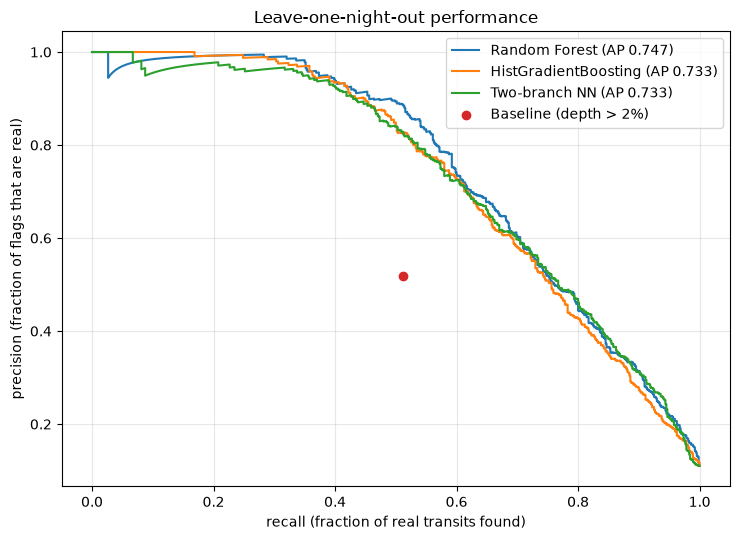

In [8]:
# Step 6b: precision-recall curves
plt.figure(figsize=(7.5, 5.5))
for name, score in scores.items():
    p, r, _ = precision_recall_curve(y, score)
    plt.plot(r, p, label=f"{name} (AP {average_precision_score(y, score):.3f})")
plt.scatter([baseline_recall], [precision_score(y, baseline_pred)], color="tab:red", zorder=5,
            label="Baseline (depth > 2%)")
plt.xlabel("recall (fraction of real transits found)")
plt.ylabel("precision (fraction of flags that are real)")
plt.title("Leave-one-night-out performance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Step 6c: how stable is each model from night to night?
stability = []
for name, score in scores.items():
    per_night = []
    for night in unique_nights:
        m = groups == night
        if y[m].sum() >= 3 and (y[m] == 0).sum() >= 3:
            per_night.append(average_precision_score(y[m], score[m]))
    stability.append({"model": name, "median AP": np.median(per_night),
                      "worst night": np.min(per_night), "best night": np.max(per_night),
                      "spread (std)": np.std(per_night)})
pd.DataFrame(stability).set_index("model").round(3)

,median AP,worst night,best night,spread (std)
model,,,,
Random Forest,0.808,0.279,0.974,0.221
HistGradientBoosting,0.786,0.244,0.977,0.243
Two-branch NN,0.796,0.264,0.970,0.236


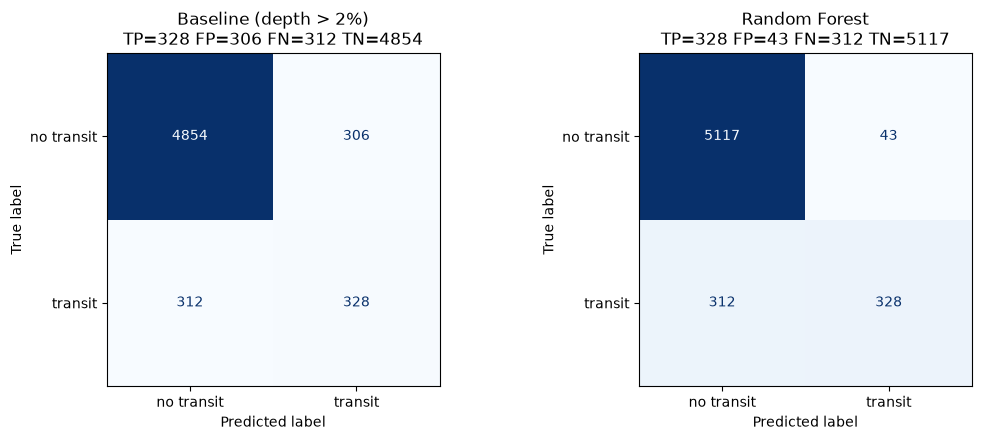

best model: Random Forest


In [10]:
# Step 6d: confusion matrix of the best model, at the baseline's recall
best_name = max(scores, key=lambda n: average_precision_score(y, scores[n]))
p, r, th = precision_recall_curve(y, scores[best_name])
j = int(np.argmin(np.abs(r[:-1] - baseline_recall)))
best_pred = (scores[best_name] >= th[j]).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, name in [(axes[0], baseline_pred, "Baseline (depth > 2%)"), (axes[1], best_pred, best_name)]:
    cm = confusion_matrix(y, pred)
    ConfusionMatrixDisplay(cm, display_labels=["no transit", "transit"]).plot(ax=ax, colorbar=False, cmap="Blues")
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name}\nTP={tp} FP={fp} FN={fn} TN={tn}")
plt.tight_layout()
plt.show()
print(f"best model: {best_name}")

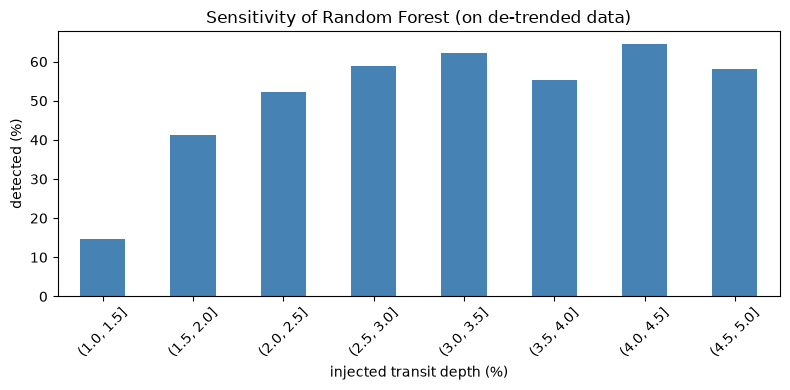

bin
(1.0, 1.5]    14.7
(1.5, 2.0]    41.2
(2.0, 2.5]    52.2
(2.5, 3.0]    59.0
(3.0, 3.5]    62.1
(3.5, 4.0]    55.2
(4.0, 4.5]    64.5
(4.5, 5.0]    58.2
Name: found, dtype: float64

In [11]:
# Step 6e: how deep must a transit be before the best model finds it?
inj = data[data.label == 1].copy()
inj["found"] = best_pred[data.label.values == 1] == 1
inj["bin"] = pd.cut(inj["injected_depth_%"], np.arange(1, 5.5, 0.5))
rate = inj.groupby("bin", observed=True).found.mean() * 100
ax = rate.plot(kind="bar", figsize=(8, 4), color="steelblue")
ax.set_ylabel("detected (%)"); ax.set_xlabel("injected transit depth (%)")
ax.set_title(f"Sensitivity of {best_name} (on de-trended data)")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()
rate.round(1)

## Step 7 — What we learned

Fill these in from the tables above when you present:

- Which model won on **average precision**, and by how much over the Random Forest of notebook 03.
- How many false positives the best model removes compared with the simple depth rule, **at the same recall**.
- How stable the models are between nights (Step 6c) — a model that is excellent on one night and poor on
  another is less trustworthy than a slightly weaker but steady one.
- The depth at which sensitivity collapses (Step 6e) — that is the honest limit of the whole project.

## Try it yourself

1. In Step 2 set `K = 0` (no de-trending) and re-run. How much of the performance came from cleaning the data rather than from the model?
2. In Step 4 delete the `dense` branch and use only the CNN. How much does the network lose without the observing conditions?
3. In Step 3 remove the middle-60% restriction. Does performance jump? If it does, that jump is the model guessing from the time of night — the thing we deliberately removed.